<center>
<a href="https://www.umontpellier.fr/"><img src="https://www.umontpellier.fr/wp-content/uploads/2022/10/logo_um_2022_rouge_rvb.svg" width="200"/></a>&nbsp;&nbsp;
<a href="https://economie.edu.umontpellier.fr/"><img src="https://economie.edu.umontpellier.fr/files/2014/12/economie_rvb_2015-300x137.png" width="160"/></a>
</center>

<div align="center">

#  Phase 3 — Nettoyage et Validation de la Base `temps.csv`

| Nom et Prénom | Rôle |
|---|---|
| Randriamisaina Tsiory-Fanomezana | Membre de l'équipe |
| SHIRALI POUR Amir | Membre de l'équipe |

</div>

---
## Objectif de cette phase

La base `temps.csv` est le **journal des interventions** : chaque ligne enregistre
un acte de traitement d'un dossier par un agent. Un même dossier peut apparaître
plusieurs fois (plusieurs agents, plusieurs sessions de travail).

Ce notebook applique les corrections décrites dans [`docs/phase3_temps.md`](../docs/phase3_temps.md).

**Statistiques initiales connues :**
- 431 598 lignes × 5 colonnes
- `duree.corrigee` : **47 471 NaN** (11%), max = 253 014 min (≈4 215h)
- Dates déjà en format ISO `YYYY/MM/DD`


---
## Section 0 — Initialisation

In [1]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

def localiser_racine_du_projet():
    """Remonte l'arborescence jusqu'à trouver la racine (présence de .git ou requirements.txt)."""
    repertoire_courant = Path.cwd()
    while True:
        if any((repertoire_courant / m).exists() for m in ['.git', 'requirements.txt']):
            break
        if repertoire_courant.parent == repertoire_courant:
            break
        repertoire_courant = repertoire_courant.parent
    if Path.cwd() != repertoire_courant:
        os.chdir(repertoire_courant)
    return repertoire_courant.resolve()

REPERTOIRE_RACINE = localiser_racine_du_projet()
sys.path.insert(0, str(REPERTOIRE_RACINE / 'src'))
from utils.dataframe_styler import style_duplicates
print(f" Racine du projet : {REPERTOIRE_RACINE}")

 Racine du projet : /Users/su6i/Documents/DU/Projet Data/projet_big_data_v2


In [2]:
# --- Chargement des bases
temps_original  = pd.read_csv('data/temps.csv', encoding='latin-1')
dossier_nettoye = pd.read_csv('data/dossier_nettoye.csv', encoding='utf-8')
ressources_nettoyees = pd.read_csv('data/ressources_nettoyees.csv', encoding='utf-8')

# Copie de travail
temps = temps_original.copy()

print(f" temps          : {temps.shape[0]:,} lignes × {temps.shape[1]} colonnes")
print(f" dossier_nettoye: {dossier_nettoye.shape[0]:,} lignes")
print(f" ressources     : {ressources_nettoyees.shape[0]:,} lignes")
print()
print("Types de données :")
print(temps.dtypes)

 temps          : 431,598 lignes × 5 colonnes
 dossier_nettoye: 98,935 lignes
 ressources     : 389,353 lignes

Types de données :
Numero.dossier              int64
Matricule                   int64
Date.debut.traitement         str
heure.debut.traitement        str
duree.corrigee            float64
dtype: object


---
## Section 1 — Vue d'ensemble de la qualité des données

In [3]:
def compter_anomalies_par_colonne(dataframe):
    """Calcule NaN, ???, total et % pour chaque colonne. Retourne DataFrame trié."""
    resultats = []
    for colonne in dataframe.columns:
        n_nan           = dataframe[colonne].isna().sum()
        n_interrogation = (dataframe[colonne].astype(str).str.strip() == '???').sum()
        total           = n_nan + n_interrogation
        resultats.append({
            'Colonne'        : colonne,
            'NaN'            : n_nan,
            '???'            : n_interrogation,
            'Total anomalies': total,
            '% du total'     : round(total / len(dataframe) * 100, 2)
        })
    return (pd.DataFrame(resultats)
              .sort_values('Total anomalies', ascending=False)
              .reset_index(drop=True))

tableau_anomalies_initial = compter_anomalies_par_colonne(temps)
print("Tableau récapitulatif des anomalies initiales :")
tableau_anomalies_initial

Tableau récapitulatif des anomalies initiales :


,Colonne,NaN,???,Total anomalies,% du total
0,duree.corrigee,47471,0,47471,11.0
1,Numero.dossier,0,0,0,0.0
2,Matricule,0,0,0,0.0
3,Date.debut.traitement,0,0,0,0.0
4,heure.debut.traitement,0,0,0,0.0


---
## Section 2 — Anomalie C1 : NaN dans `duree.corrigee` (47 471 lignes)

### Constat
47 471 lignes (11%) n'ont pas de durée de traitement enregistrée.

### Décision : Conservation avec NaN — aucune imputation
> Imputer par la médiane introduirait un biais dans les analyses de performance des agents.  
> Ces lignes restent utiles pour les analyses de fréquence et de présence.  
> Elles seront **exclues uniquement** des modèles nécessitant cette variable.

In [4]:
n_nan_duree = temps['duree.corrigee'].isna().sum()
pct_nan     = n_nan_duree / len(temps) * 100

print(f"NaN dans duree.corrigee : {n_nan_duree:,} ({pct_nan:.2f}%)")
print()
print("Statistiques des valeurs non-NaN :")
print(temps['duree.corrigee'].describe())
print()
print("Aperçu d'exemples avec NaN :")
temps[temps['duree.corrigee'].isna()].head(5).style_duplicates(
    highlight_mask=temps['duree.corrigee'].isna()
)

NaN dans duree.corrigee : 47,471 (11.00%)

Statistiques des valeurs non-NaN :
count    384127.000000
mean        312.310377
std         581.611424
min           5.000000
25%          52.000000
50%         188.000000
75%         411.000000
max      253014.000000
Name: duree.corrigee, dtype: float64

Aperçu d'exemples avec NaN :


,Numero.dossier,Matricule,Date.debut.traitement,heure.debut.traitement,duree.corrigee
375207,8198256,1864,2022/03/12,10:16:15,nan
375208,8198271,496,2022/08/05,17:08:25,nan
375209,8198271,2584,2022/11/04,14:02:41,nan
375210,8198271,378,2022/09/30,10:23:11,nan
375211,8198271,2125,2022/08/05,13:59:00,nan


---
## Section 3 — Anomalie C2 : Valeurs aberrantes dans `duree.corrigee`

### Constat
Maximum observé : **253 014 minutes** (≈ 175 jours). La médiane est 188 min.

### Décision : Signalement avec seuil de vigilance — conservation sans suppression
> Seuil d'alerte : durée > **1 440 min** (24 heures = 1 journée complète).  
> Ces cas seront traités comme outliers dans les modèles (Phase 5 & 6).

In [5]:
SEUIL_DUREE_MAX_MINUTES = 1440  # 24 heures

masque_duree_aberrante = temps['duree.corrigee'] > SEUIL_DUREE_MAX_MINUTES

print(f"Interventions > {SEUIL_DUREE_MAX_MINUTES} min (24h) : {masque_duree_aberrante.sum():,}")
print(f"Soit {masque_duree_aberrante.mean()*100:.2f}% des lignes avec durée renseignée")
print()
print("Percentiles de duree.corrigee :")
percentiles = [50, 75, 90, 95, 99, 99.9]
for p in percentiles:
    val = temps['duree.corrigee'].quantile(p/100)
    print(f"  P{p:5.1f} : {val:>10,.1f} min ({val/60:.1f}h)")

Interventions > 1440 min (24h) : 8,612
Soit 2.00% des lignes avec durée renseignée

Percentiles de duree.corrigee :
  P 50.0 :      188.0 min (3.1h)
  P 75.0 :      411.0 min (6.8h)
  P 90.0 :      736.0 min (12.3h)
  P 95.0 :    1,035.0 min (17.2h)
  P 99.0 :    1,912.0 min (31.9h)
  P 99.9 :    3,687.9 min (61.5h)


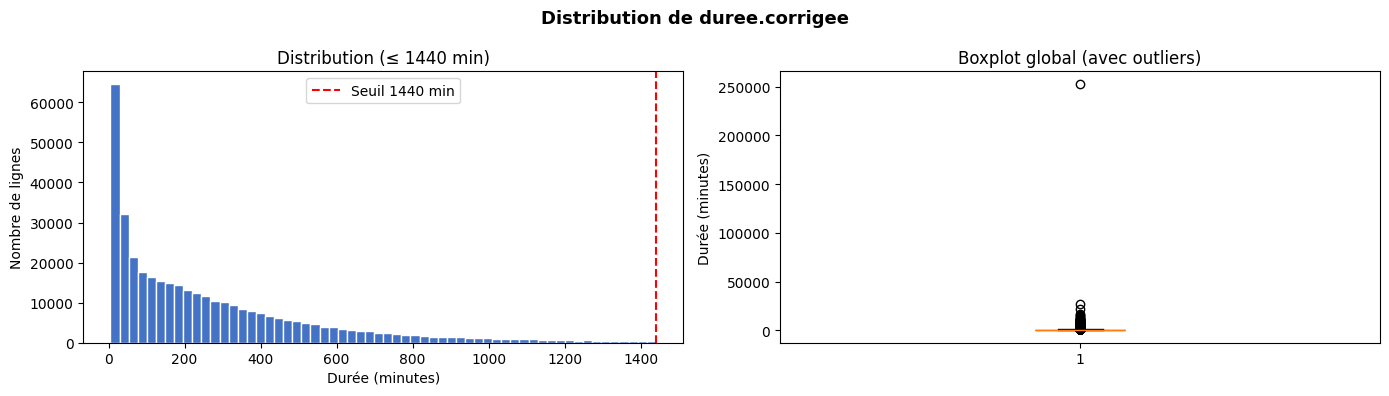

→ Outliers signalés — conservation sans suppression (décision C2)


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("Distribution de duree.corrigee", fontsize=13, fontweight='bold')

# Histogramme (sans outliers extrêmes pour lisibilité)
duree_sans_extremes = temps['duree.corrigee'].dropna()
duree_sans_extremes = duree_sans_extremes[duree_sans_extremes <= 1440]
axes[0].hist(duree_sans_extremes, bins=60, color='#4472c4', edgecolor='white')
axes[0].axvline(SEUIL_DUREE_MAX_MINUTES, color='red', linestyle='--', label=f'Seuil {SEUIL_DUREE_MAX_MINUTES} min')
axes[0].set_title("Distribution (≤ 1440 min)")
axes[0].set_xlabel("Durée (minutes)")
axes[0].set_ylabel("Nombre de lignes")
axes[0].legend()

# Boxplot global
axes[1].boxplot(temps['duree.corrigee'].dropna(), vert=True, patch_artist=True,
               boxprops=dict(facecolor='#4472c4', alpha=0.7))
axes[1].set_title("Boxplot global (avec outliers)")
axes[1].set_ylabel("Durée (minutes)")

plt.tight_layout()
plt.savefig('data/phase3_duree_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("→ Outliers signalés — conservation sans suppression (décision C2)")

---
## Section 4 — Anomalie C3 : Dates hors de la période 2021–2022

### Constat
`temps` doit couvrir la même période que `dossier` (2021–2022).

### Décision : Suppression des lignes hors période
> Contrairement à `ressources`, `temps` est une table de transactions directement liées aux dossiers.  
> Une intervention hors de la période 2021–2022 est hors-scope par construction.

In [7]:
DATE_DEBUT_PERIODE = '2021/01/01'
DATE_FIN_PERIODE   = '2022/12/31'

masque_date_hors_periode = (
    (temps['Date.debut.traitement'] < DATE_DEBUT_PERIODE) |
    (temps['Date.debut.traitement'] > DATE_FIN_PERIODE)
)

print(f"Lignes hors période 2021–2022 : {masque_date_hors_periode.sum():,}")

if masque_date_hors_periode.sum() > 0:
    print()
    print("Distribution des années hors-période :")
    print(temps[masque_date_hors_periode]['Date.debut.traitement'].str[:4].value_counts())
    print()
    print("Aperçu :")
    temps[masque_date_hors_periode].head(5).style_duplicates(
        highlight_mask=masque_date_hors_periode
    )
else:
    print(" Toutes les dates sont dans la période 2021–2022")

Lignes hors période 2021–2022 : 0
 Toutes les dates sont dans la période 2021–2022


In [8]:
if masque_date_hors_periode.sum() > 0:
    nombre_avant_suppression = len(temps)
    temps.drop(index=temps[masque_date_hors_periode].index, inplace=True)
    temps.reset_index(drop=True, inplace=True)
    print(f" {nombre_avant_suppression - len(temps):,} lignes hors-période supprimées")
    print(f" Taille résultante : {len(temps):,} lignes")
    n_restants = ((temps['Date.debut.traitement'] < DATE_DEBUT_PERIODE) |
                  (temps['Date.debut.traitement'] > DATE_FIN_PERIODE)).sum()
    assert n_restants == 0, f" {n_restants} lignes hors-période subsistent !"
    print(" Vérification : 0 date hors-période restante ")
else:
    print(" Aucune suppression nécessaire")

 Aucune suppression nécessaire


---
## Section 5 — Anomalies C4 & C5 : Cross-référence avec `dossier_nettoye`

### C4 — Dossiers dans `temps` absents de `dossier_nettoye`
> Signalement uniquement — ces dossiers seront exclus naturellement lors du LEFT JOIN en Phase 4.

### C5 — Dossiers dans `dossier_nettoye` absents de `temps`
> Signalement uniquement — ces dossiers n'ont pas d'intervention enregistrée (peut être informatif).

In [9]:
ensemble_ids_temps   = set(temps['Numero.dossier'].dropna().astype(int))
ensemble_ids_dossier = set(dossier_nettoye['Numero_dossier_ID'].dropna().astype(int))

ids_temps_sans_dossier  = ensemble_ids_temps - ensemble_ids_dossier
ids_dossier_sans_temps  = ensemble_ids_dossier - ensemble_ids_temps

print(f"Dossiers uniques dans temps    : {len(ensemble_ids_temps):,}")
print(f"Dossiers uniques dans dossier  : {len(ensemble_ids_dossier):,}")
print()
print(f"  C4 — Dans temps mais PAS dans dossier : {len(ids_temps_sans_dossier):,}")
print(f"   → Seront naturellement exclus lors du LEFT JOIN (Phase 4)")
print()
print(f"  C5 — Dans dossier mais PAS dans temps : {len(ids_dossier_sans_temps):,}")
print(f"   → Dossiers sans intervention enregistrée — durée = NaN après jointure")
print()
# Proportion de dossiers couverts
pct_couverts = (len(ensemble_ids_dossier) - len(ids_dossier_sans_temps)) / len(ensemble_ids_dossier) * 100
print(f" Couverture : {pct_couverts:.1f}% des dossiers ont au moins une intervention dans temps")

Dossiers uniques dans temps    : 107,732
Dossiers uniques dans dossier  : 98,935

  C4 — Dans temps mais PAS dans dossier : 10,977
   → Seront naturellement exclus lors du LEFT JOIN (Phase 4)

  C5 — Dans dossier mais PAS dans temps : 2,180
   → Dossiers sans intervention enregistrée — durée = NaN après jointure

 Couverture : 97.8% des dossiers ont au moins une intervention dans temps


---
## Section 6 — Anomalie C6 : Doublons `Numero.dossier + Matricule + Date + Heure`

### Constat
Un agent peut légitimement traiter le même dossier plusieurs fois (reprises).  
Seuls les **doublons exacts** (même dossier, même agent, même date ET même heure) sont suspects.

### Décision : Suppression des doublons exacts uniquement

In [10]:
# Doublons exacts (toutes les 4 colonnes identiques)
masque_doublons_exacts = temps.duplicated(
    subset=['Numero.dossier', 'Matricule', 'Date.debut.traitement', 'heure.debut.traitement'],
    keep=False
)
nombre_doublons_exacts = masque_doublons_exacts.sum()

print(f"Doublons exacts (Dossier + Matricule + Date + Heure) : {nombre_doublons_exacts:,}")

# Interventions multiples légitimes (même dossier + matricule, dates différentes)
nb_dossier_multi_sessions = (
    temps.groupby(['Numero.dossier', 'Matricule']).size()
    .reset_index(name='nb_sessions')
)
print(f"Paires (Dossier, Matricule) avec plusieurs sessions : "
      f"{(nb_dossier_multi_sessions['nb_sessions'] > 1).sum():,}")
print(f"Paires avec 1 seule session : "
      f"{(nb_dossier_multi_sessions['nb_sessions'] == 1).sum():,}")

if nombre_doublons_exacts > 0:
    print()
    print("Aperçu des doublons exacts :")
    temps[masque_doublons_exacts].head(6).style_duplicates(
        id_column='Numero.dossier'
    )

Doublons exacts (Dossier + Matricule + Date + Heure) : 0
Paires (Dossier, Matricule) avec plusieurs sessions : 60,590
Paires avec 1 seule session : 261,076


In [11]:
if nombre_doublons_exacts > 0:
    nombre_avant = len(temps)
    temps.drop_duplicates(
        subset=['Numero.dossier', 'Matricule', 'Date.debut.traitement', 'heure.debut.traitement'],
        keep='first', inplace=True
    )
    temps.reset_index(drop=True, inplace=True)
    print(f" {nombre_avant - len(temps):,} doublon(s) exact(s) supprimé(s)")
    print(f" Taille résultante : {len(temps):,} lignes")
else:
    print(" Aucun doublon exact — pas d'action requise")

 Aucun doublon exact — pas d'action requise


---
## Section 7 — Anomalie C7 : Validation du format `heure.debut.traitement`

### Constat
Les heures doivent être au format `HH:MM:SS`. Vérification systématique.

### Décision : Remplacement par NaN si invalide

In [12]:
# Vérification format HH:MM:SS via parsing pandas
masque_heures_invalides_temps = (
    ~pd.to_datetime(temps['heure.debut.traitement'], format='%H:%M:%S', errors='coerce').notna()
    & temps['heure.debut.traitement'].notna()
)

nombre_heures_invalides = masque_heures_invalides_temps.sum()
print(f"Heures invalides dans heure.debut.traitement : {nombre_heures_invalides:,}")

if nombre_heures_invalides > 0:
    print("Valeurs invalides :")
    print(temps[masque_heures_invalides_temps]['heure.debut.traitement'].value_counts().head(10))
    temps.loc[masque_heures_invalides_temps, 'heure.debut.traitement'] = np.nan
    print(f" {nombre_heures_invalides:,} heures invalides → NaN")
else:
    print(" Toutes les heures sont au format HH:MM:SS")

Heures invalides dans heure.debut.traitement : 0
 Toutes les heures sont au format HH:MM:SS


---
## Section 8 — Anomalie C8 : Cross-référence Matricule ↔ `ressources`

### Constat
Les matricules de `temps` doivent correspondre à des agents connus dans `ressources`.

### Décision : Quantification et signalement

In [13]:
ensemble_matricules_temps      = set(temps['Matricule'].dropna().astype(int))
ensemble_matricules_ressources = set(ressources_nettoyees['Matricule'].dropna().astype(int))

matricules_temps_sans_ressources = ensemble_matricules_temps - ensemble_matricules_ressources

n_lignes_agents_orphelins = temps[temps['Matricule'].isin(matricules_temps_sans_ressources)].shape[0]

print(f"Matricules uniques dans temps     : {len(ensemble_matricules_temps):,}")
print(f"Matricules uniques dans ressources: {len(ensemble_matricules_ressources):,}")
print()
print(f"  Matricules dans temps mais ABSENT de ressources : {len(matricules_temps_sans_ressources)}")
print(f"   Lignes concernées : {n_lignes_agents_orphelins:,}")
if matricules_temps_sans_ressources:
    print(f"   Matricule(s) : {sorted(list(matricules_temps_sans_ressources))[:10]}")
    print("   → Signalé pour investigation — lignes conservées")
else:
    print(" Tous les matricules de temps existent dans ressources")

Matricules uniques dans temps     : 2,442
Matricules uniques dans ressources: 2,507

  Matricules dans temps mais ABSENT de ressources : 1
   Lignes concernées : 2
   Matricule(s) : [1852]
   → Signalé pour investigation — lignes conservées


---
## Section 9 — Synthèse et tableau de bord de qualité

In [14]:
bilan_transformations = pd.DataFrame([
    {'N°': 'C1', 'Anomalie': 'NaN dans duree.corrigee',          'N initial': 47471, 'Action': 'Conservation (NaN significatifs)'},
    {'N°': 'C2', 'Anomalie': 'Outliers duree > 1440 min',        'N initial': '?',   'Action': 'Signalé — traitement en Phase 5&6'},
    {'N°': 'C3', 'Anomalie': 'Dates hors période 2021–2022',     'N initial': '?',   'Action': 'Suppression'},
    {'N°': 'C4', 'Anomalie': 'Dossiers temps sans dossier',      'N initial': 10977, 'Action': 'Signalé — exclus via JOIN Phase 4'},
    {'N°': 'C5', 'Anomalie': 'Dossiers sans intervention temps', 'N initial': 2180,  'Action': 'Signalé — durée NaN après JOIN'},
    {'N°': 'C6', 'Anomalie': 'Doublons exacts (4 colonnes)',     'N initial': '?',   'Action': 'Suppression (keep=first)'},
    {'N°': 'C7', 'Anomalie': 'Heures invalides format HH:MM:SS', 'N initial': '?',   'Action': 'Remplacement par NaN'},
    {'N°': 'C8', 'Anomalie': 'Matricules orphelins (ressources)','N initial': '?',   'Action': 'Signalé — investigation future'},
])
print("Bilan des transformations Phase 3 :")
bilan_transformations

Bilan des transformations Phase 3 :


,N°,Anomalie,N initial,Action
0,C1,NaN dans duree.corrigee,47471,Conservation (NaN significatifs)
1,C2,Outliers duree > 1440 min,?,Signalé — traitement en Phase 5&6
2,C3,Dates hors période 2021–2022,?,Suppression
3,C4,Dossiers temps sans dossier,10977,Signalé — exclus via JOIN Phase 4
4,C5,Dossiers sans intervention temps,2180,Signalé — durée NaN après JOIN
5,C6,Doublons exacts (4 colonnes),?,Suppression (keep=first)
6,C7,Heures invalides format HH:MM:SS,?,Remplacement par NaN
7,C8,Matricules orphelins (ressources),?,Signalé — investigation future


In [15]:
print(f"=== ÉTAT FINAL DE LA BASE temps ===")
print(f"Lignes initiales  : {len(temps_original):,}")
print(f"Lignes finales    : {len(temps):,}")
print(f"Lignes supprimées : {len(temps_original) - len(temps):,}")
print()
print("Valeurs manquantes restantes :")
manquants_finaux = temps.isna().sum()
for col, n in manquants_finaux[manquants_finaux > 0].items():
    pct = n / len(temps) * 100
    print(f"  {col}: {n:,} ({pct:.2f}%)")
print()
print("Aperçu des 5 premières lignes :")
temps.head(5).style_duplicates()

=== ÉTAT FINAL DE LA BASE temps ===
Lignes initiales  : 431,598
Lignes finales    : 431,598
Lignes supprimées : 0

Valeurs manquantes restantes :
  duree.corrigee: 47,471 (11.00%)

Aperçu des 5 premières lignes :


,Numero.dossier,Matricule,Date.debut.traitement,heure.debut.traitement,duree.corrigee
0,5465153,1979,2021/07/03,20:04:14,217.000000
1,5465153,1323,2021/07/07,12:29:55,690.000000
2,5465153,1735,2021/07/07,14:31:38,297.000000
3,5465153,1979,2021/07/03,19:42:12,719.000000
4,5465153,706,2021/07/03,18:16:36,44.000000


---
## Section 10 — Export de la base nettoyée

In [16]:
CHEMIN_SORTIE = 'data/temps_nettoye.csv'
temps.to_csv(CHEMIN_SORTIE, index=False, encoding='utf-8')

print(f" Base nettoyée exportée : {CHEMIN_SORTIE}")
print(f"   {temps.shape[0]:,} lignes × {temps.shape[1]} colonnes")

# Vérification rapide
temps_verifie = pd.read_csv(CHEMIN_SORTIE)
assert len(temps_verifie) == len(temps), " Divergence dans le fichier exporté !"
print(f" Vérification export : {len(temps_verifie):,} lignes lues ")

 Base nettoyée exportée : data/temps_nettoye.csv
   431,598 lignes × 5 colonnes
 Vérification export : 431,598 lignes lues 
